In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import scipy
from tqdm import tqdm   

### Gerchberg-Saxton Algorithm

Gaussian input and target

5.729577951308231e-06


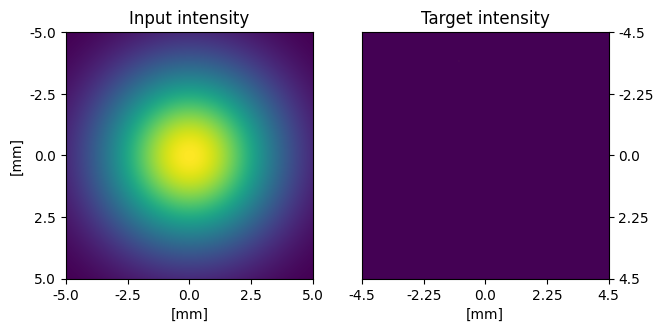

In [36]:
#Gaussian input and target field

N = 1000 # resolution
array_size = 1e-2
dx = array_size / N

N_spots = 1
wavelength = 900e-9
f = 1e-1

sigma_input = array_size/4
sigma_target = wavelength * f / (2*np.pi*sigma_input)
print(sigma_target)

# pupil-plane coordinates
x = (np.arange(N) - N//2) * dx
y = (np.arange(N) - N//2) * dx
X, Y = np.meshgrid(x, y)

# fourier-plane coordinates
fx = (np.arange(N) - N//2) * wavelength * f / (N * dx)
fy = (np.arange(N) - N//2) * wavelength * f/ (N * dx)
fX, fY = np.meshgrid(fx, fy)

#input_intensity = np.ones((N_pixels, N_pixels))
input_intensity = np.ones((N, N))#np.exp(-(X**2 + Y**2) / (2 * sigma_input**2))
input_intensity = np.exp(-(X**2 + Y**2) / (2 * sigma_input**2))
input_intensity /= np.sum(input_intensity)

fieldsize_fplane = wavelength * f / dx

positions = [(0, 0)]#fieldsize_fplane/4)]
positions = np.random.uniform(0, 1, size=(N_spots, 2))*fieldsize_fplane/2

target_intensity = np.zeros((N, N))

shape = 'point'

for x, y in positions:
    if shape =='Gaussian':
        target_intensity += np.exp(-((fX-x)**2 + (fY-y)**2) / (2 * sigma_target**2))
    elif shape == 'point':
        target_intensity[int(x*N/fieldsize_fplane), int(y*N/fieldsize_fplane)] = 1



target_intensity *= np.sum(input_intensity) / np.sum(target_intensity) # demand energy conservation


def plot_intensities(input_intensity, target_intensity):
    fig, axs = plt.subplots(1, 2, figsize=(7, 14))

    ticks_res = 4
    ticks = np.arange(0, N+1, N//ticks_res)
    pupil_ticks = np.round(np.arange(-array_size/2, array_size/2+1/N, array_size/ticks_res)*1e3, 2)
    fplane_ticks = np.round(np.arange(-fieldsize_fplane/2, fieldsize_fplane/2+1/N, fieldsize_fplane/ticks_res)*1e3, 2)
    
    axs[0].set_title('Input intensity')
    axs[0].imshow(input_intensity)
    axs[0].set_xticks(ticks, pupil_ticks)
    axs[0].set_yticks(ticks, pupil_ticks)
    axs[0].set_xlabel('[mm]')
    axs[0].set_ylabel('[mm]')

    axs[1].set_title('Target intensity')
    axs[1].imshow(target_intensity)
    axs[1].set_xticks(ticks, fplane_ticks)
    axs[1].set_yticks(ticks, fplane_ticks)
    axs[1].yaxis.tick_right()
    axs[1].yaxis.set_label_position("right")    
    axs[1].set_xlabel('[mm]')

    plt.show()



plot_intensities(input_intensity, target_intensity)

  0%|          | 0/41 [00:00<?, ?it/s]

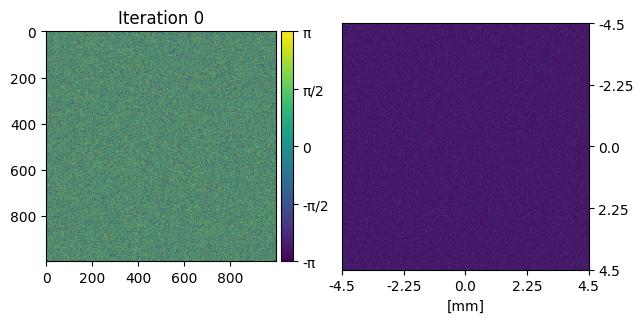

 24%|██▍       | 10/41 [00:03<00:08,  3.57it/s]

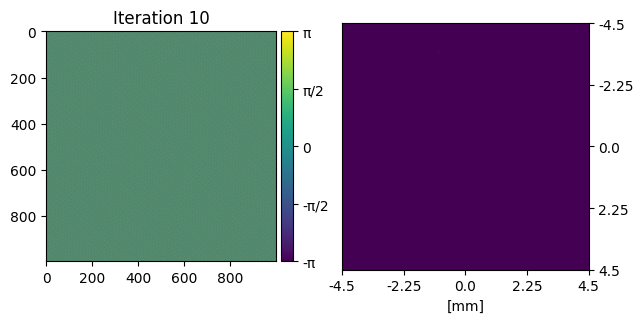

 49%|████▉     | 20/41 [00:06<00:05,  3.79it/s]

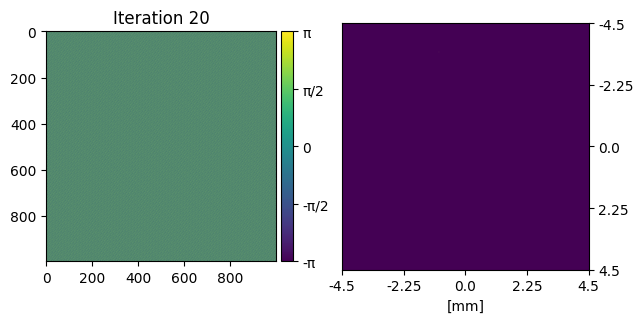

 73%|███████▎  | 30/41 [00:09<00:02,  3.81it/s]

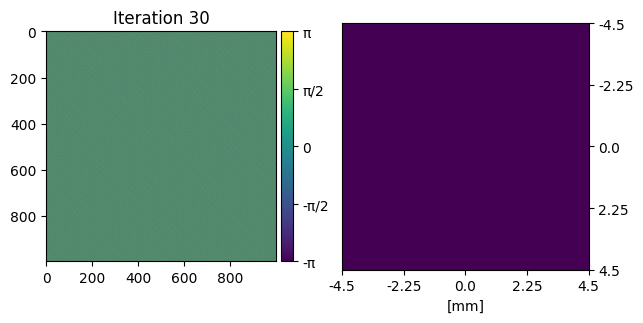

 98%|█████████▊| 40/41 [00:12<00:00,  3.71it/s]

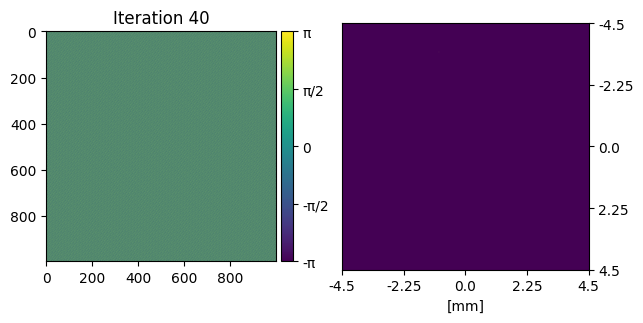

100%|██████████| 41/41 [00:13<00:00,  3.03it/s]


In [37]:
def Gerchberg_Saxton(input_amp : np.array,
                     target_amp : np.array,
                     initial_phase : np.array,
                     N_iterations : int = 1000,
                     plot_every : int = 100) -> np.array:
    
    phase_beam = initial_phase

    for i in tqdm(range(N_iterations+1)):
        field_beam = input_amp * np.exp(1j*phase_beam)

        field_focus = np.fft.fftshift(np.fft.fft2(field_beam))
        phase_focus = np.angle(field_focus)

        if i % plot_every == 0 or i == N_iterations:
            ticks_res = 4
            ticks = np.arange(0, N+1, N//ticks_res)
            fplane_ticks = np.round(np.arange(-fieldsize_fplane/2, fieldsize_fplane/2+1/N, fieldsize_fplane/ticks_res)*1e3, 2)

            phase_ticks = [-np.pi, -np.pi/2, 0, np.pi/2, np.pi]
            phase_tick_names = ['-π', '-π/2', 0, 'π/2', 'π']

            fig, axs = plt.subplots(1, 2, figsize=(7, 14))

            axs[0].set_title(f'Iteration {i}')
            im_phase = axs[0].imshow(phase_beam)
            divider = make_axes_locatable(axs[0])
            cax = divider.append_axes("right", size="5%", pad=0.05)
            cbar = fig.colorbar(im_phase, cax=cax)
            cbar.set_ticks(phase_ticks)
            cbar.set_ticklabels(phase_tick_names)

            axs[1].imshow(np.abs(field_focus)**2)
            axs[1].set_xticks(ticks, fplane_ticks)
            axs[1].set_yticks(ticks, fplane_ticks)
            axs[1].yaxis.tick_right()
            axs[1].yaxis.set_label_position("right")    
            axs[1].set_xlabel('[mm]')
            plt.show()
        
        field_focus = target_amp * np.exp(1j*phase_focus)

        field_beam = np.fft.ifft2(np.fft.ifftshift(field_focus))
        phase_beam = np.angle(field_beam)
        #

    return phase_beam


initial_phase = (np.random.rand(N, N) * 2 - 1)*np.pi


phasemask = Gerchberg_Saxton(input_amp = np.sqrt(input_intensity),
                             target_amp = np.sqrt(target_intensity),
                             initial_phase = initial_phase,
                             N_iterations = 40,
                             plot_every = 10)


### add a quadratic phase term

[[-1.6572661  -2.33585012 -3.01443413 ...  0.37848594 -0.30009808
  -0.97868209]
 [ 2.21945923  1.54087522  0.8622912  ... -2.02797404 -2.70655805
   2.89804324]
 [-0.18700074 -0.86558476 -1.54416877 ...  1.8487513   1.17016728
   0.49158327]
 ...
 [-0.72107149 -1.39965551 -2.07823952 ...  1.31468055  0.63609653
  -0.04248748]
 [-3.12753147  2.47706983  1.79848581 ... -1.09177943 -1.77036344
  -2.44894745]
 [ 0.74919387  0.07060986 -0.60797416 ...  2.78494591  2.10636189
   1.42777788]]


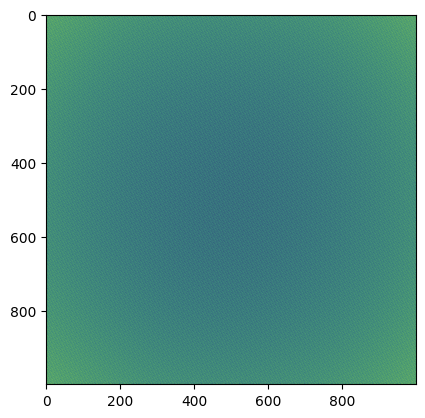

In [38]:
print(phasemask)

f = 100
phasemask_defocus = phasemask + np.pi*(X**2 + Y**2) / wavelength / f

plt.imshow(phasemask_defocus)

In [39]:
phasemask = phasemask_defocus

### Lee Holography

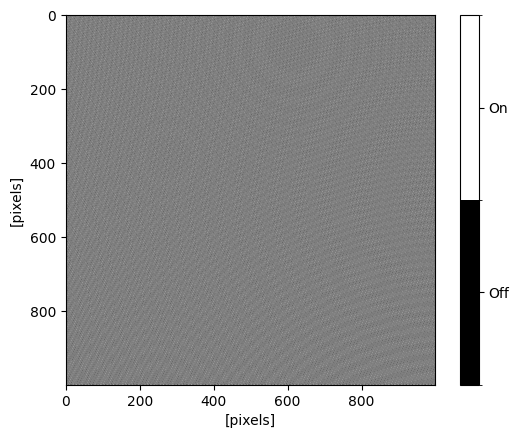

In [46]:
carrier_period = 146 #pixels
carrier_freq = 1/(carrier_period*dx)
fringes = (1 + np.cos(carrier_freq*(X+Y) - phasemask))/2

binary_fringes = np.zeros_like(fringes)
binary_fringes[fringes>1/2] = 1



from matplotlib.colors import ListedColormap, BoundaryNorm

cmap = ListedColormap(['black', 'white'])
norm = BoundaryNorm([0, 0.5, 1], cmap.N)
fig, ax = plt.subplots()
im = plt.imshow(binary_fringes, cmap=cmap, norm=norm)
cbar = plt.colorbar(im, ticks=[0.25, 0.75])
cbar.set_ticklabels(['Off', 'On'])

ax.set_xlabel('[pixels]')
ax.set_ylabel('[pixels]')

plt.show()

### propagate beam after fringes

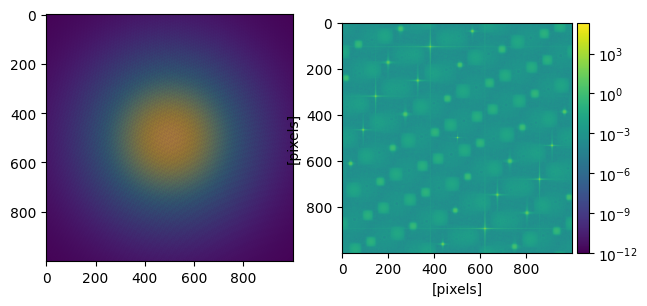

In [47]:
from matplotlib.colors import LogNorm

beam = input_intensity * binary_fringes



field_focus = np.fft.fftshift(np.fft.fft2(np.sqrt(beam)))

fig, axs = plt.subplots(1, 2, figsize=(7, 14))
axs[0].imshow(beam)
im = axs[1].imshow(np.abs(field_focus)**2, norm=LogNorm(vmin=1e-12))
divider = make_axes_locatable(axs[1])
cax = divider.append_axes("right", size="5%", pad=0.05)
cbar = fig.colorbar(im, cax=cax)
axs[1].set_xlabel('[pixels]')
axs[1].set_ylabel('[pixels]')
plt.show()

1.1683314080344066e-06 6.674133910975644e-07 0.4998646355712436 0.5001335286839572


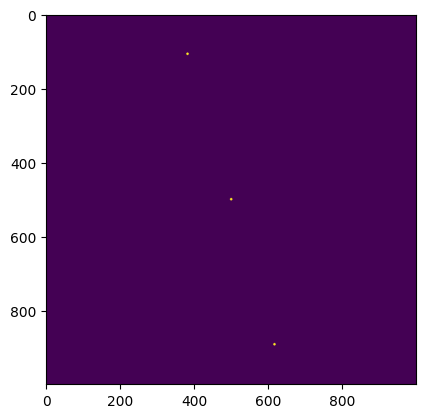

In [42]:
r = 5*sigma_target*N/fieldsize_fplane

intensity_focus =  np.abs(field_focus)**2 / np.sum(np.abs(field_focus)**2)

mask_plus = np.zeros_like(field_focus)
mask_min = np.zeros_like(field_focus)
rows, cols = np.shape(field_focus)
Y, X = np.ogrid[:rows, :cols]

for (x, y) in positions:
    m, n = int(N/2 + x*N/fieldsize_fplane), int(N/2 + y*N/fieldsize_fplane)
    k, l = int(N/2 - x*N/fieldsize_fplane), int(N/2 - y*N/fieldsize_fplane)

    mask_plus += (X - m)**2 + (Y - n)**2 < r**2
    mask_min += (X - k)**2 + (Y - l)**2 < r**2
    
mask_plusorder = np.real(mask_plus) > 0
mask_minorder = np.real(mask_min) > 0
mask_zeroorder = (X - N//2)**2 + (Y - N//2)**2 < r**2
plt.imshow(mask_plusorder+mask_minorder+mask_zeroorder)

loss_plusorder = np.sum(intensity_focus[mask_plusorder])
loss_minorder = np.sum(intensity_focus[mask_minorder])
loss_zeroorder = np.sum(intensity_focus[mask_zeroorder])
otherloss = 1-loss_plusorder-loss_minorder-loss_zeroorder

print(loss_plusorder, loss_minorder, loss_zeroorder, otherloss)


In [43]:
loss0 = []
loss1 = []
lossmin1 = []
lossother = []

periods = np.arange(1, 200, 1)

for carrier_period in periods:     #pixels
    carrier_freq = 1/(carrier_period*dx)
    fringes = (1 + np.cos(carrier_freq*(X+Y) - phasemask))/2

    binary_fringes = np.zeros_like(fringes)
    binary_fringes[fringes>1/2] = 1

    beam = input_intensity * binary_fringes
    field_focus = np.fft.fftshift(np.fft.fft2(np.sqrt(beam)))
    
    r = 10*sigma_target*N/fieldsize_fplane

    intensity_focus =  np.abs(field_focus)**2 / np.sum(np.abs(field_focus)**2)
    #plt.imshow(intensity_focus*(mask_plusorder+mask_plusorder+mask_plusorder))
    #plt.show()

    loss_plusorder = np.sum(intensity_focus[mask_plusorder])
    loss_minorder = np.sum(intensity_focus[mask_minorder])
    loss_zeroorder = np.sum(intensity_focus[mask_zeroorder])
    otherloss = 1-loss_plusorder-loss_minorder-loss_zeroorder

    loss0.append(loss_zeroorder*100)
    loss1.append(loss_plusorder*100)
    lossmin1.append(loss_minorder*100)
    lossother.append(otherloss*100)

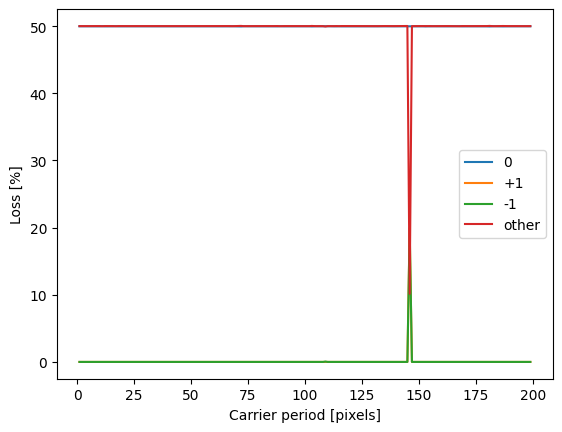

In [44]:
plt.plot(periods, loss0, label='0')
plt.plot(periods, loss1, label='+1')
plt.plot(periods, lossmin1, label='-1')
plt.plot(periods, lossother, label='other')
plt.legend()
plt.xlabel('Carrier period [pixels]')
plt.ylabel('Loss [%]')
#plt.xlim(165, 185)
plt.show()

In [45]:
print(np.max(loss1))
periods[np.argmax(loss1)]

19.85844742986636


np.int64(146)